Columns: Index(['image_id', 'street', 'citi', 'n_citi', 'bed', 'bath', 'sqft', 'price'], dtype='object')
Using price column: price


C:\Users\Laptop\AppData\Local\Temp\ipykernel_20956\1991412430.py:42: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model_cnn = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')



===== RESULTS =====
MAE: 287535.47
RMSE: 475359.59

Sample Predictions:
Actual: 270000 | Predicted: 421377.56

Sample Predictions:
Actual: 300000 | Predicted: 35360.84

Sample Predictions:
Actual: 234900 | Predicted: 288660.16

Sample Predictions:
Actual: 299000 | Predicted: 287118.16

Sample Predictions:
Actual: 250000 | Predicted: 536747.75

Sample Predictions:
1. Actual: 270000 | Predicted: 421377.5625
2. Actual: 300000 | Predicted: 35360.83984375
3. Actual: 234900 | Predicted: 288660.15625
4. Actual: 299000 | Predicted: 287118.15625
5. Actual: 250000 | Predicted: 536747.75


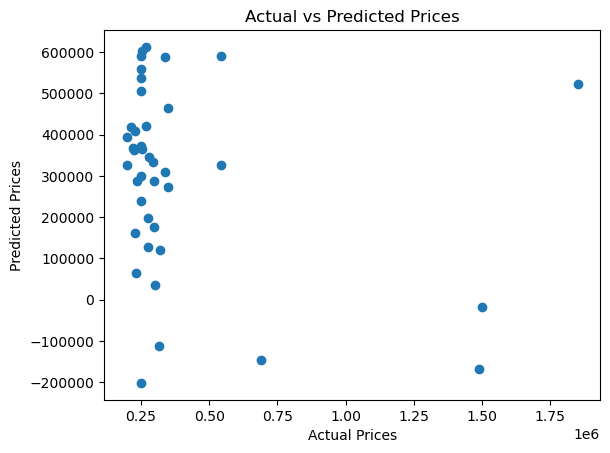

In [3]:
# =========================
# TASK 3 CLEAN VERSION
# =========================

import os
import random
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------
# 1. LOAD DATA (YOUR PATH)
# -------------------------
df = pd.read_csv("socal2.csv")
img_folder = "socal2/socal_pics"

print("Columns:", df.columns)

# -------------------------
# 2. FIX PRICE COLUMN NAME
# -------------------------
# Auto-detect price column
price_col = None
for col in df.columns:
    if "price" in col.lower():
        price_col = col
        break

if price_col is None:
    raise ValueError("No price column found")

print("Using price column:", price_col)

# -------------------------
# 3. LOAD CNN MODEL
# -------------------------
model_cnn = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

def extract(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return model_cnn.predict(img, verbose=0)[0]

# -------------------------
# 4. GET IMAGE FILES
# -------------------------
image_files = os.listdir(img_folder)

# -------------------------
# 5. CREATE DATA (SIMPLIFIED)
# -------------------------
features = []
prices = []

# Use only first 200 rows (FASTER + SAFE)
for i in range(min(200, len(df))):
    row = df.iloc[i]

    try:
        img_name = random.choice(image_files)
        img_path = os.path.join(img_folder, img_name)

        feat = extract(img_path)

        features.append(feat)
        prices.append(row[price_col])

    except:
        continue

# -------------------------
# 6. TRAIN MODEL
# -------------------------
X = np.array(features)
y = np.array(prices)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

# -------------------------
# 7. RESULTS
# -------------------------
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\n===== RESULTS =====")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

print("\nSample Predictions:")
for i in range(min(5, len(y_test))):
    print("Actual:", y_test[i], "| Predicted:", round(preds[i], 2))
    print("\nSample Predictions:")
for i in range(min(5, len(y_test))):
    print(f"{i+1}. Actual: {y_test[i]} | Predicted: {round(preds[i], 2)}")

# -------------------------
# 8. VISUALIZATION
# -------------------------
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y_test, preds)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()